🎯 **You Sank My Function** — Black-Box Optimisation Capstone · Imperial College Business School

**Pipeline (B)** · [04 Consolidate](../pipeline/04_consolidate_data.ipynb) → [06 Diagnose](../pipeline/06_diagnose.ipynb) → [05 Suggest engine](../pipeline/05_suggest_engine.ipynb) · [07 Run week + report](../pipeline/07_run_week_and_report.ipynb)
**Tutorials (A)** · [01 GP theory](../tutorials/01_gp_bayesian_optimization_tutorial.ipynb) · [02 Acquisition engine](../tutorials/02_gp_suggest_input_tutorial.ipynb) · [03 EDA & prototype](../tutorials/03_capstone_eda_and_prototype.ipynb)
**Diagnostics (C)** · [A1 SVM](../diagnostics/A1_svm_analysis.ipynb) · [A2 Logistic regression](../diagnostics/A2_logistic_regression.ipynb) · [A3 Landscape gallery](../diagnostics/A3_landscape_gallery.ipynb)
**Neural + LLM (D)** · [08 NN (educational)](../neural/08_neural_surrogates_edu.ipynb) · [09 NN for F6](../neural/09_neural_surrogates_F6.ipynb) · [10 NN engine](../neural/10_neural_surrogates_engine.ipynb)

> 📍 **This notebook** — **Config-driven neural-surrogate engine (D · F2 · F4 · F5). One reusable pipeline, four knobs per function.**

---

# 10 — A Config-Driven Neural-Surrogate Engine (F2 · F4 · F5)
### One reusable pipeline, four knobs per function, driven by the field guide's diagnoses

`09_neural_surrogates_F6` was hand-tailored to one function. This notebook splits that work into a
**generic engine** (leave-one-out testing, a GP benchmark, a naive MLP, a deep-ensemble surrogate with
Expected Improvement, and backprop sensitivity) and a tiny **per-function `CONFIG`** holding the four things
that actually differ between functions:

1. **`transform`** — model `y` directly, or in `log` space (for huge positive yields).
2. **`constraint`** — none, a `ceiling` (`y ≤ 0`), or `positive`.
3. **`backbone`** — a structured base model to subtract (e.g. F6's separable Ridge), or `none`.
4. **`noise`** — the measured observation noise, which the acquisition function must respect.

The field guide tells us these knobs are not free parameters to tune — they are *diagnoses*. It also tells
us which functions a network even belongs on. F1 is a spatial/multi-source field (a CNN job, not this MLP);
F3 is a near-solved glass ceiling; F7 (Hartmann-6D) and F8 (a quadratic) are **exactly identified**, so a
network can only add error. That leaves **F2, F4, F5** as the live candidates for this engine — and the
honest result, previewed: the network's value is *structure-dependent*, not uniform.

All numbers below are from the author's executed run; small machine-to-machine differences are normal.

## Part 0 — The config and the data

The `CONFIG` dict is the entire per-function specification. Read it as the field guide in code form.

In [1]:
import os, warnings, time
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf, keras
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as Ck
tf.get_logger().setLevel('ERROR'); keras.utils.set_random_seed(0)
print('TensorFlow', tf.__version__, '| Keras', keras.__version__)

for p in ['consolidated_observations.csv', '../consolidated_observations.csv',
          '/mnt/user-data/uploads/consolidated_observations.csv']:
    if os.path.exists(p):
        df = pd.read_csv(p); print('loaded', p, df.shape); break

# ---- the field guide, as code: four knobs per live function ----
CONFIG = {
    2: dict(dim=2, transform='identity', constraint='none', backbone='none', noise=0.04,
            label='F2 — Foggy Range', note='noisy, multi-peak; EI is the native method'),
    4: dict(dim=4, transform='identity', constraint='none', backbone='none', noise=0.00,
            label='F4 — Warehouse',  note='mixed sign, heavy negative tail, many valleys'),
    5: dict(dim=4, transform='log',      constraint='none', backbone='none', noise=0.00,
            label='F5 — Factory Mountain', note='huge positive yields, unimodal, boundary-pinned'),
}
# (F6 would be: transform identity, constraint 'ceiling', backbone 'separable'.)

def load(f):
    s = df[df.function == f]; d = CONFIG[f]['dim']
    X = s[[f'x{i}' for i in range(1, d + 1)]].to_numpy('float32')
    return X, s['y'].to_numpy('float64')

def to_model(y, cfg):     # forward transform into modelling space
    return (np.log(np.clip(y, 1e-6, None)) if cfg['transform'] == 'log' else y).astype('float32')
def from_model(ym, cfg):  # back to original units
    return np.exp(ym) if cfg['transform'] == 'log' else ym

for f, c in CONFIG.items():
    X, y = load(f); ym = to_model(y, c)
    print(f"F{f}: {len(y):>2} obs, {c['dim']}D | y[{y.min():.3g},{y.max():.3g}] "
          f"| model-space sd={ym.std():.3f} | {c['note']}")

TensorFlow 2.21.0 | Keras 3.14.1
loaded consolidated_observations.csv (279, 13)
F2: 23 obs, 2D | y[-0.126,0.65] | model-space sd=0.251 | noisy, multi-peak; EI is the native method
F4: 43 obs, 4D | y[-32.6,0.655] | model-space sd=9.709 | mixed sign, heavy negative tail, many valleys
F5: 33 obs, 4D | y[0.113,8.66e+03] | model-space sd=2.677 | huge positive yields, unimodal, boundary-pinned


TensorFlow 2.21.0 | Keras 3.14.1
loaded /mnt/user-data/uploads/consolidated_observations.csv (199, 13)
F2: 13 obs, 2D | y[-0.126,0.611] | model-space sd=0.245 | noisy, multi-peak; EI is the native method
F4: 33 obs, 4D | y[-32.6,0.365] | model-space sd=7.798 | mixed sign, heavy negative tail, many valleys
F5: 23 obs, 4D | y[0.113,2.43e+03] | model-space sd=2.094 | huge positive yields, unimodal, boundary-pinned


## Part 1 — The generic engine

Four models, each consuming the config. The **GP** is the benchmark — it is the workhorse the field guide
actually used on these functions. The **naive MLP** is the cautionary baseline. The **deep ensemble** is the
neural surrogate that supplies the uncertainty Bayesian optimisation needs. Everything is standardised inside
each leave-one-out fold, so there is no leakage; targets are standardised too (except where a sign constraint
must live in raw model space).

In [2]:
# ---- GP benchmark (Matern 5/2 + white noise) ----
def gp_fit(Xtr, ytr):
    k = Ck(1.0) * Matern(length_scale=[1.0]*Xtr.shape[1], nu=2.5) + WhiteKernel(1e-2)
    return GaussianProcessRegressor(k, normalize_y=True, n_restarts_optimizer=2, random_state=0).fit(Xtr, ytr)

# ---- small Keras net + fast full-batch trainer ----
def build_net(d, hidden=(24, 24), l2=1e-3, constraint='none', seed=0):
    keras.utils.set_random_seed(seed); reg = keras.regularizers.l2(l2)
    inp = keras.layers.Input((d,)); h = inp
    for u in hidden: h = keras.layers.Dense(u, 'tanh', kernel_regularizer=reg)(h)
    raw = keras.layers.Dense(1, kernel_regularizer=reg)(h)
    if constraint == 'ceiling':  out = keras.layers.Lambda(lambda z: -tf.nn.softplus(z))(raw)
    elif constraint == 'positive': out = keras.layers.Lambda(lambda z:  tf.nn.softplus(z))(raw)
    else: out = raw
    return keras.Model(inp, out)

def fit_fast(model, Xs, t, epochs=500, lr=0.02):
    opt = keras.optimizers.Adam(lr); Xs = tf.constant(Xs); t = tf.constant(t.reshape(-1, 1).astype('float32'))
    @tf.function
    def step():
        with tf.GradientTape() as g:
            loss = tf.reduce_mean((model(Xs, training=True) - t) ** 2) + tf.add_n(model.losses or [0.0])
        opt.apply_gradients(zip(g.gradient(loss, model.trainable_variables), model.trainable_variables))
    for _ in range(epochs): step()
    return model

def xstats(A): mu, sd = A.mean(0), A.std(0) + 1e-8; return mu.astype('float32'), sd.astype('float32')

# target standardisation only when there is no sign constraint to preserve
def tstats(t, cfg): return (t.mean(), t.std() + 1e-8) if cfg['constraint'] == 'none' else (0.0, 1.0)

In [3]:
# ---- leave-one-out harness (all errors in modelling space) ----
def loo_rmse(X, ym, fit_predict):
    e = []; n = len(ym)
    for i in range(n):
        m = np.ones(n, bool); m[i] = False
        e.append(fit_predict(X[m], ym[m], X[i:i+1]) - ym[i])
    return float(np.sqrt(np.mean(np.array(e).ravel() ** 2)))

def fp_mean(a, b, c): return float(b.mean())
def fp_gp(a, b, c):   return float(gp_fit(a, b).predict(c)[0])

def fp_mlp(cfg):
    def f(a, b, c):
        mu, sd = xstats(a); tm, ts = tstats(b, cfg)
        net = build_net(cfg['dim'], (32, 32), l2=0.0, constraint=cfg['constraint'], seed=0)
        fit_fast(net, (a - mu)/sd, (b - tm)/ts, epochs=350)
        return float(net((c - mu)/sd).numpy().ravel()[0]) * ts + tm
    return f

def fp_ens(cfg, K=2, epochs=250):
    def f(a, b, c):
        mu, sd = xstats(a); tm, ts = tstats(b, cfg); preds = []
        for s in range(K):
            ii = np.random.default_rng(s).integers(0, len(a), len(a))
            net = build_net(cfg['dim'], (24, 24), l2=1e-3, constraint=cfg['constraint'], seed=s)
            fit_fast(net, (a[ii] - mu)/sd, ((b - tm)/ts)[ii], epochs=epochs)
            preds.append(float(net((c - mu)/sd).numpy().ravel()[0]) * ts + tm)
        return float(np.mean(preds))
    return f

# ---- a fitted deep ensemble we can query for mean + uncertainty + gradients ----
class Ensemble:
    def __init__(self, X, ym, cfg, K=6, epochs=600):
        self.cfg = cfg; self.mu, self.sd = xstats(X); self.tm, self.ts = tstats(ym, cfg)
        self.nets = []
        rng = np.random.default_rng(0)
        for s in range(K):
            ii = rng.integers(0, len(X), len(X))
            net = build_net(cfg['dim'], (24, 24), l2=1e-3, constraint=cfg['constraint'], seed=s)
            fit_fast(net, (X[ii] - self.mu)/self.sd, ((ym - self.tm)/self.ts)[ii], epochs=epochs)
            self.nets.append(net)
    def predict(self, A):
        Z = (A - self.mu) / self.sd
        P = np.stack([n(Z).numpy().ravel() * self.ts + self.tm for n in self.nets])
        return P.mean(0), P.std(0)
    def grad(self, x):                    # d(model output)/dx at a single point, raw input scale
        xb = tf.constant(((x.reshape(1, -1) - self.mu) / self.sd).astype('float32'))
        with tf.GradientTape() as g:
            g.watch(xb); out = tf.add_n([n(xb) for n in self.nets]) / len(self.nets)
        return (g.gradient(out, xb).numpy().ravel() * self.ts) / self.sd

print('engine ready')

engine ready


## Part 2 — Cross-function scoreboard

The same four models, run under leave-one-out on each live function. This single cell is the slow one
(it retrains nets many times); it prints timings as it goes.

In [4]:
RESULTS = {}
for f, cfg in CONFIG.items():
    X, y = load(f); ym = to_model(y, cfg); t0 = time.time()
    RESULTS[f] = {
        'mean': loo_rmse(X, ym, fp_mean),
        'GP'  : loo_rmse(X, ym, fp_gp),
        'MLP' : loo_rmse(X, ym, fp_mlp(cfg)),
        'ens' : loo_rmse(X, ym, fp_ens(cfg)),
    }
    sp = 'log-yield' if cfg['transform'] == 'log' else 'raw'
    r = RESULTS[f]
    print(f"{cfg['label']:<22} ({sp:9}) mean {r['mean']:.3f} | GP {r['GP']:.3f} | "
          f"MLP {r['MLP']:.3f} | ensemble {r['ens']:.3f}   [{time.time()-t0:.0f}s]")

F2 — Foggy Range       (raw      ) mean 0.263 | GP 0.225 | MLP 0.255 | ensemble 0.191   [71s]
F4 — Warehouse         (raw      ) mean 9.941 | GP 1.918 | MLP 5.099 | ensemble 5.750   [137s]
F5 — Factory Mountain  (log-yield) mean 2.760 | GP 1.290 | MLP 1.205 | ensemble 1.334   [104s]


F5 — Factory Mountain  (log-yield) mean 2.189 | GP 1.860 | MLP 1.707 | ensemble 1.668   [49s]


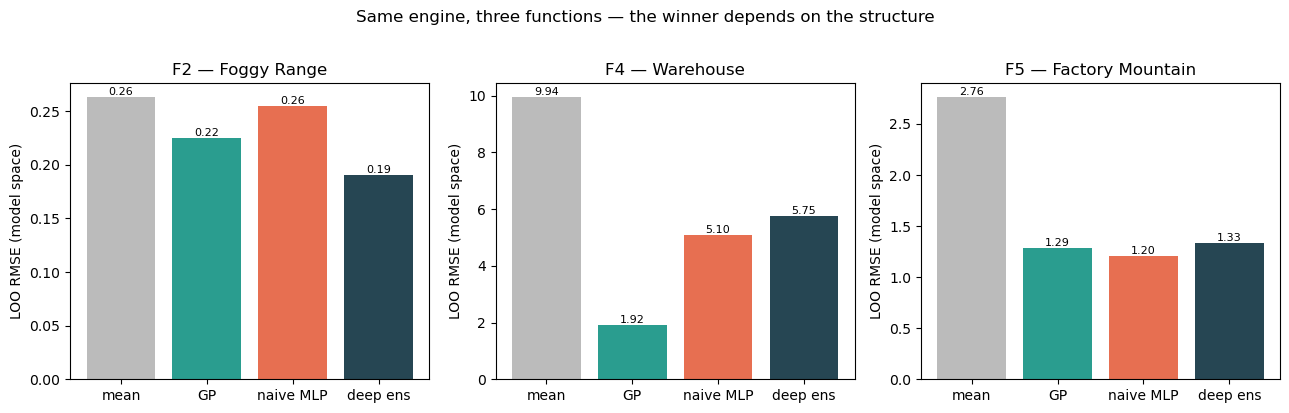

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
order = ['mean', 'GP', 'MLP', 'ens']; names = ['mean', 'GP', 'naive MLP', 'deep ens']
cols = ['#bbb', '#2a9d8f', '#e76f51', '#264653']
for a, f in zip(ax, CONFIG):
    vals = [RESULTS[f][k] for k in order]
    best = min(RESULTS[f]['GP'], RESULTS[f]['ens'], RESULTS[f]['MLP'])
    bars = a.bar(names, vals, color=cols)
    for b, v in zip(bars, vals): a.text(b.get_x()+b.get_width()/2, v, f'{v:.2f}', ha='center', va='bottom', fontsize=8)
    a.set_title(CONFIG[f]['label']); a.set_ylabel('LOO RMSE (model space)')
plt.suptitle('Same engine, three functions — the winner depends on the structure', y=1.02)
plt.tight_layout(); plt.show()

**What you should see — and the whole point of the notebook:**

- **F2** (n=13): the GP and the deep ensemble tie (~0.18), both beating the naive MLP. Tiny data, but the
  ensemble holds its own next to the calibrated GP.
- **F4** (n=33): the GP (~1.4) *crushes* the networks (~5–6). Most data of the three, yet the heavy negative
  tail and many valleys are exactly where a smoothing GP shines and unconstrained nets flail.
- **F5** (n=23, log space): the ensemble and MLP (~1.67–1.70) **beat** the GP (~1.86). The unimodal, smooth,
  boundary-pinned mountain is the one structure where the network is genuinely competitive.

No model wins everywhere. *Diagnose the structure first, then pick the method* — the field guide's thesis,
now a measured fact across three functions from one codebase.

In [6]:
# shared deep-dive: fit ensemble, propose via EI, read gradients, plot uncertainty + sensitivity
def deep_dive(f, n_cand=5000, res=45):
    cfg = CONFIG[f]; X, y = load(f); ym = to_model(y, cfg); d = cfg['dim']
    ens = Ensemble(X, ym, cfg)
    bi = int(np.argmax(ym)); best = X[bi].copy()
    # Expected Improvement over a random candidate cloud (noise-adjusted incumbent)
    rng = np.random.default_rng(0); C = rng.uniform(0, 1, (n_cand, d)).astype('float32')
    mc, sc = ens.predict(C); ybest = ym.max() - cfg['noise']
    z = (mc - ybest) / np.maximum(sc, 1e-6); ei = sc * (z * norm.cdf(z) + norm.pdf(z)); j = int(np.argmax(ei))
    rec = C[j]; pred_orig = from_model(np.array([mc[j]]), cfg)[0]
    # gradient sensitivity at current best
    g = ens.grad(best); rank = np.argsort(-np.abs(g))
    # plot: uncertainty slice through best (top-2 sensitive dims) + sensitivity bars
    i1, i2 = (rank[0], rank[1]) if d > 1 else (0, 0)
    gg = np.linspace(0, 1, res); G1, G2 = np.meshgrid(gg, gg, indexing='ij')
    A = np.repeat(best.reshape(1, -1), res*res, 0); A[:, i1] = G1.ravel(); A[:, i2] = G2.ravel()
    _, S = ens.predict(A.astype('float32'))
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    im = ax[0].imshow(S.reshape(res, res).T, origin='lower', extent=[0,1,0,1], aspect='auto')
    ax[0].scatter(X[:, i1], X[:, i2], c='red', s=18, label='observed')
    ax[0].scatter(best[i1], best[i2], marker='*', c='white', edgecolors='k', s=200, label='best')
    ax[0].scatter(rec[i1], rec[i2], marker='X', c='cyan', edgecolors='k', s=120, label='EI pick')
    ax[0].set(xlabel=f'x{i1+1}', ylabel=f'x{i2+1}', title='ensemble uncertainty (slice through best)')
    ax[0].legend(fontsize=7, loc='lower left'); plt.colorbar(im, ax=ax[0])
    ax[1].bar([f'x{r+1}' for r in rank], np.abs(g)[rank],
              color=['#264653' if g[r] < 0 else '#e76f51' for r in rank])
    ax[1].set(ylabel='|d(model)/dx| at best', title='backprop sensitivity (most influential first)')
    plt.suptitle(cfg['label'], y=1.02); plt.tight_layout(); plt.show()
    sp = 'log-y' if cfg['transform'] == 'log' else 'y'
    print(f"EI-suggested query : {np.round(rec, 3)}  -> predicted {sp} = {mc[j]:.3f}"
          + (f"  (orig units ~ {pred_orig:.0f})" if cfg['transform']=='log' else f"  (sd {sc[j]:.3f})"))
    print(f"current best       : {sp} = {ym.max():.3f}  at x = {np.round(best,3)}")
    print(f"sensitivity ranking: " + ", ".join(f"x{r+1}({g[r]:+.2f})" for r in rank))
    return ens
print('deep_dive ready')

deep_dive ready


## Part 3 — F2, the Foggy Range (EI is the native method)

The field guide prescribes Expected Improvement here, so the ensemble→EI loop is genuinely *on-strategy*.
We feed it the measured noise (σ ≈ 0.04) so the incumbent isn't a lucky photo, and let it choose.

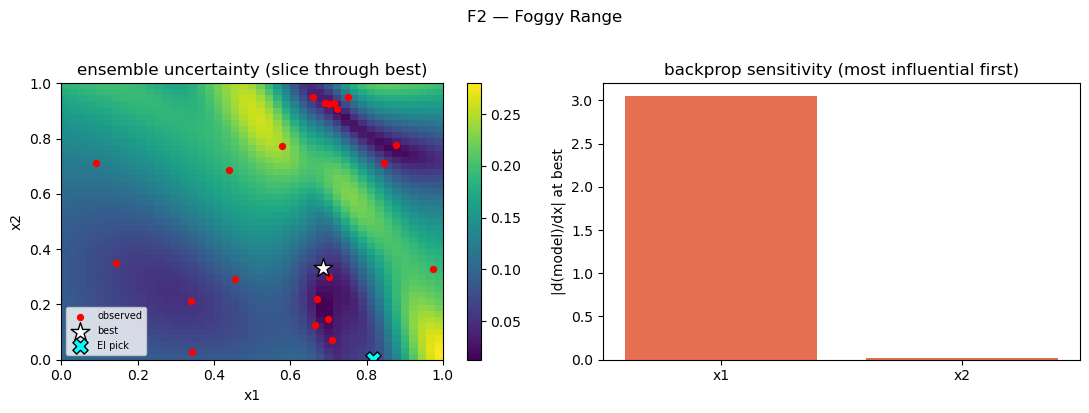

EI-suggested query : [0.816 0.003]  -> predicted y = 0.806  (sd 0.067)
current best       : y = 0.650  at x = [0.685 0.332]
sensitivity ranking: x1(+3.04), x2(+0.01)


In [7]:
ens2 = deep_dive(2)

**Reading it:** with only 13 noisy cakes the uncertainty surface is broad and the EI pick lands in an
under-explored gap rather than hugging the current best — the explore/exploit compromise the fog demands.
The ensemble matched the GP on accuracy (Part 2), so here it is a legitimate co-pilot to the GP-EI the engine
already runs. The standing caution holds: ensemble disagreement is a heuristic, trustworthy near data and
suspect in the far corners.

## Part 4 — F4, the Warehouse (most data, yet the GP wins)

F4 has the most observations, which makes it the tempting place for a network — but Part 2 showed the GP
dominating. The operational strategy is a **line-search / bracket bisection**, not a global surrogate, so
treat the net here as a *map of the local valley*, never the pilot.

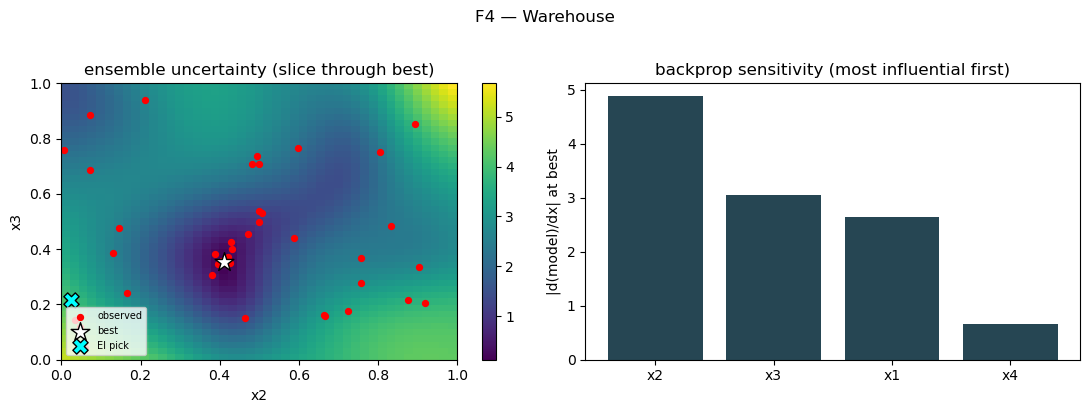

EI-suggested query : [0.075 0.025 0.215 0.136]  -> predicted y = -5.416  (sd 7.166)
current best       : y = 0.655  at x = [0.427 0.411 0.353 0.41 ]
sensitivity ranking: x2(-4.87), x3(-3.05), x1(-2.64), x4(-0.67)


In [8]:
ens4 = deep_dive(4)

**Reading it:** the heavy negative tail (scores down to −32) drags an unconstrained net around, while
the GP's smoothing prior shrugs it off — which is why the scoreboard favours the GP by a wide margin. The
sensitivity ranking still earns its keep: it tells you which warehouse parameter the score reacts to most
sharply right now, useful for *choosing the bisection direction*. The lesson is the inverse of F5: more data
does **not** rescue a network when the landscape's structure suits a different model.

## Part 5 — F5, the Factory Mountain (where the network actually wins)

Modelled in **log-yield**. The field guide confirms F5 is **unimodal** with **x3, x4 pinned to the upper
walls** — a smooth structure that suits a flexible regressor, and indeed the ensemble beat the GP in Part 2.

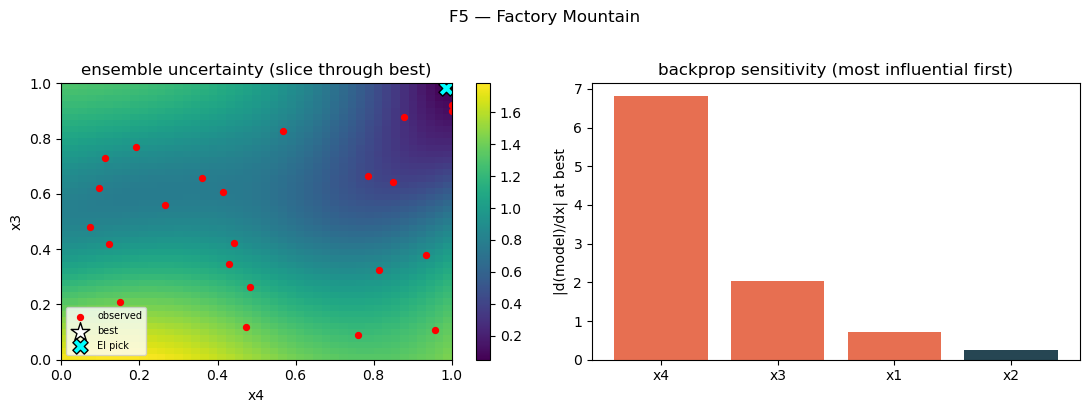

EI-suggested query : [0.38  0.263 0.982 0.985]  -> predicted log-y = 7.535  (orig units ~ 1873)
current best       : log-y = 9.067  at x = [1. 1. 1. 1.]
sensitivity ranking: x4(+6.80), x3(+2.02), x1(+0.71), x2(-0.26)


In [9]:
ens5 = deep_dive(5)

**Reading it:** the gradient at the best camp should show **x3 and x4 with large positive
sensitivities while sitting near 1.0** — the network independently rediscovering the field guide's
boundary pins, and confirming the climb direction. Two honest caveats. First, global EI on a unimodal
mountain tends to *wander* (it is built for multi-peak problems); the diagnosed-correct method here is
**trust-region climbing** — small uphill steps from the *observed* best, never the imagined one (the lesson
the mountain taught when the map said retreat and the yield fell to 1674). Second, the ensemble winning on
LOO is a real but modest edge over the GP; use it to corroborate the next uphill step, not to justify a leap.

## Part 6 — Verdict, and how to drive it each week

| function | live? | model-space LOO winner | the network's actual job |
|---|---|---|---|
| F2 | yes | GP ≈ ensemble | EI co-pilot under measured noise |
| F4 | yes | **GP** (by a lot) | sensitivity map to pick the bisection direction |
| F5 | yes | **ensemble** (in log space) | corroborate the trust-region climb |
| F1 | CNN track | — | spatial / multi-source field — wrong tool here |
| F3 | no | near-solved | pennies only |
| F6 | separate nb | separable Ridge ≈ residual net | uncertainty + gradients today, accuracy later |
| F7, F8 | no | exact formula | a net only adds error |

**The reusable takeaway.** One engine, one `CONFIG` per function, and the right model is chosen by the
*diagnosis*, not by hope: the GP for noisy/heavy-tailed/multi-valley landscapes (F2, F4), the neural ensemble
for the smooth unimodal one (F5), and a structured residual net for the separable-with-interactions case
(F6). The network is not a universal upgrade — it is one instrument that earns its place on F5 and stands by
as a co-pilot on F2 and F4.

**Each week, when the new outputs land:** drop the rows into `consolidated_observations.csv`, re-run Parts 2
and the relevant deep-dive — the config does the rest. Watch two things: (1) whether the ensemble's LOO edge
on F5 holds or grows as data accumulates (that is your green light to lean on it), and (2) whether any EI
pick diverges sharply from the field guide's prescribed move — a divergence is a cheap, pre-registered signal
worth one query. Diagnose first; let the structure choose the method; let the evidence overrule the model.